In [1]:
import os
os.chdir("<repo-root>")
os.getcwd()

'<repo-root>'

Processing gamma=1.00e-05
  Global kraus in 0.13s
  Global optimise in 1.33s
  Local kraus in 0.18s
  Local optimise in 1.59s
Processing gamma=2.15e-05
  Global kraus in 0.11s
  Global optimise in 2.16s
  Local kraus in 0.18s
  Local optimise in 1.46s
Processing gamma=4.64e-05
  Global kraus in 0.11s
  Global optimise in 5.98s
  Local kraus in 0.18s
  Local optimise in 2.51s
Processing gamma=1.00e-04
  Global kraus in 0.11s
  Global optimise in 1.66s
  Local kraus in 0.18s
  Local optimise in 2.94s
Processing gamma=2.15e-04
  Global kraus in 0.11s
  Global optimise in 2.18s
  Local kraus in 0.18s
  Local optimise in 2.26s
Processing gamma=4.64e-04
  Global kraus in 0.13s
  Global optimise in 2.47s
  Local kraus in 0.18s
  Local optimise in 2.16s
Processing gamma=1.00e-03
  Global kraus in 0.13s
  Global optimise in 2.34s
  Local kraus in 0.19s
  Local optimise in 1.70s
Processing gamma=2.15e-03
  Global kraus in 0.13s
  Global optimise in 3.01s
  Local kraus in 0.19s
  Local optimise i

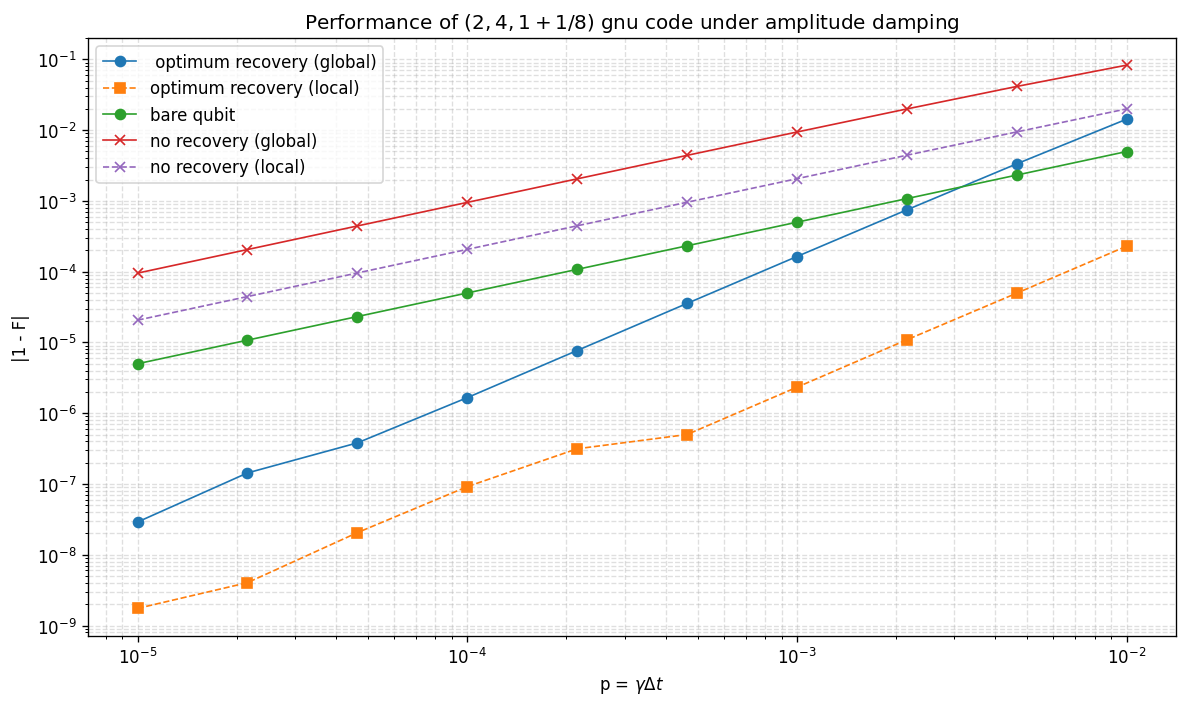

In [12]:
import qutip
import matplotlib
from qutip.piqs.piqs  import *
import numpy as np
import os
import time
import gc
# Optional: set MOSEKLM_LICENSE_FILE to your local MOSEK license path if using MOSEK.
from qer.noisemodel import*
from qer.codewords import*
from qer.optimisation import*
import matplotlib.pyplot as plt

gamma = np.logspace(-5, -2, 10)
dt = 1
p_vals = np.array(gamma) * dt

plt.figure(figsize=(10, 6), dpi = 120)

#bare qubit for comparison
rho_bare = 0.5 * qeye(2)
infids_bare_global = []

#method: kraus or choi
method = 'choi'
method_norecovery = 'kraus'

g=2
n=4
t=1
u=1+t/(g*n)
N = int(g * n * u)

rho, l0, l1 = gnucode_piqs(g, n, u, return_qutip=True)
infids_global = []
infids_local = []
infids_norecovery_global = []
infids_norecovery_local = []

for g in gamma:
    print(f"Processing gamma={g:.2e}")

    try:
        # Global amplitude damping
        t0 = time.perf_counter()
        kraus_global = noisemodel('global symmetric amplitude damping', N, g, dt, method)
        t1 = time.perf_counter()
        print(f"  Global kraus in {t1 - t0:.2f}s")

        fid_global = optimise(l0, l1, kraus_global, solver='mosek')
        t2 = time.perf_counter()
        print(f"  Global optimise in {t2 - t1:.2f}s")
        
        infids_global.append(abs(1.0 - float(fid_global)))

        #gnu code without recovery operation
        infids_norecovery_global.append(abs(1.0 - float(no_recovery(rho, noisemodel('global symmetric amplitude damping',N, g, dt, method_norecovery)))))

        #bare qubit infidelity for comparison
        fid_bare_global = optimise(qutip.basis(2,0), qutip.basis(2,1), noisemodel('global symmetric amplitude damping',1,g,dt,method))
        infids_bare_global.append(abs(1.0 - float(fid_bare_global)))
        
        # Delete large objects immediately after use
        del kraus_global
        gc.collect()  # Force garbage collection
        
    except Exception as e:
        print(f"  ERROR (global): {e}")
        infids_global.append(np.nan)

    try:
        # Local amplitude damping
        t3 = time.perf_counter()
        kraus_local = noisemodel('local symmetric amplitude damping', N, g, dt, method)
        t4 = time.perf_counter()
        print(f"  Local kraus in {t4 - t3:.2f}s")

        fid_local = optimise(l0, l1, kraus_local, solver='mosek')
        t5 = time.perf_counter()
        print(f"  Local optimise in {t5 - t4:.2f}s")
        
        infids_local.append(abs(1.0 - float(fid_local)))

        #gnu code without recovery operation
        infids_norecovery_local.append(abs(1.0 - float(no_recovery(rho, noisemodel('local symmetric amplitude damping',N, g, dt, method_norecovery)))))
        
        # Delete large objects immediately after use
        del kraus_local
        gc.collect()  # Force garbage collection
        
    except Exception as e:
        print(f"  ERROR (local): {e}")
        infids_local.append(np.nan)

# Process results
infids_global = np.array(infids_global, dtype=float) #gnu code after recovery
infids_bare_global = np.array(infids_bare_global, dtype=float) #bare qubit
infids_local = np.array(infids_local, dtype=float) #gnu code after recovery
infids_norecovery_global = np.array(infids_norecovery_global, dtype=float)#gnu code without recovery
infids_norecovery_local = np.array(infids_norecovery_local, dtype=float)#gnu code without recovery

mask_global = (infids_global > 0) & np.isfinite(infids_global)
mask_local = (infids_local > 0) & np.isfinite(infids_local)
mask_bare_global = (infids_bare_global > 0) & np.isfinite(infids_bare_global)
mask_infids_norecovery_global = (infids_norecovery_global > 0) & np.isfinite(infids_norecovery_global)
mask_infids_norecovery_local = (infids_norecovery_local > 0) & np.isfinite(infids_norecovery_local)

if np.any(mask_global):
    #plt.loglog(p_vals[mask_global], infids_global[mask_global], "o-", lw=1, label=f"gnu ({b},{g_code},{m}) optimum recovery (global)")
    plt.loglog(p_vals[mask_global], infids_global[mask_global], "o-", lw=1, label=f" optimum recovery (global)")
if np.any(mask_local):
    #plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"bgm ({b},{g_code},{m}) optimum recovery (local)")
    plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"optimum recovery (local)")
if np.any(mask_bare_global):
    plt.loglog(p_vals[mask_bare_global], infids_bare_global[mask_bare_global], "o-", lw=1, label="bare qubit")
if np.any(mask_infids_norecovery_global):
    #plt.loglog(p_vals[mask_infids_norecovery_global], infids_norecovery_global[mask_infids_norecovery_global], "x-", lw=1, label=f"gnu ({b},{g_code},{m}) no recovery (global)")
    plt.loglog(p_vals[mask_infids_norecovery_global], infids_norecovery_global[mask_infids_norecovery_global], "x-", lw=1, label=f"no recovery (global)")
if np.any(mask_infids_norecovery_local):
    #plt.loglog(p_vals[mask_infids_norecovery_local], infids_norecovery_local[mask_infids_norecovery_local], "x--", lw=1, label=f"gnu ({b},{g_code},{m}) no recovery (local)")
    plt.loglog(p_vals[mask_infids_norecovery_local], infids_norecovery_local[mask_infids_norecovery_local], "x--", lw=1, label=f"no recovery (local)")

# Clean up large objects for this code
#del rho, l0, l1, infids_global, infids_local, infids_bare_global, infids_norecovery_global, infids_norecovery_local
#gc.collect()

plt.xlabel("p = " + r"$\gamma \Delta t$")
plt.ylabel("|1 - F|")
plt.title("Performance of $(2,4,1+1/8)$ gnu code under amplitude damping")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Compare the 4-qubit Code with this gnu code

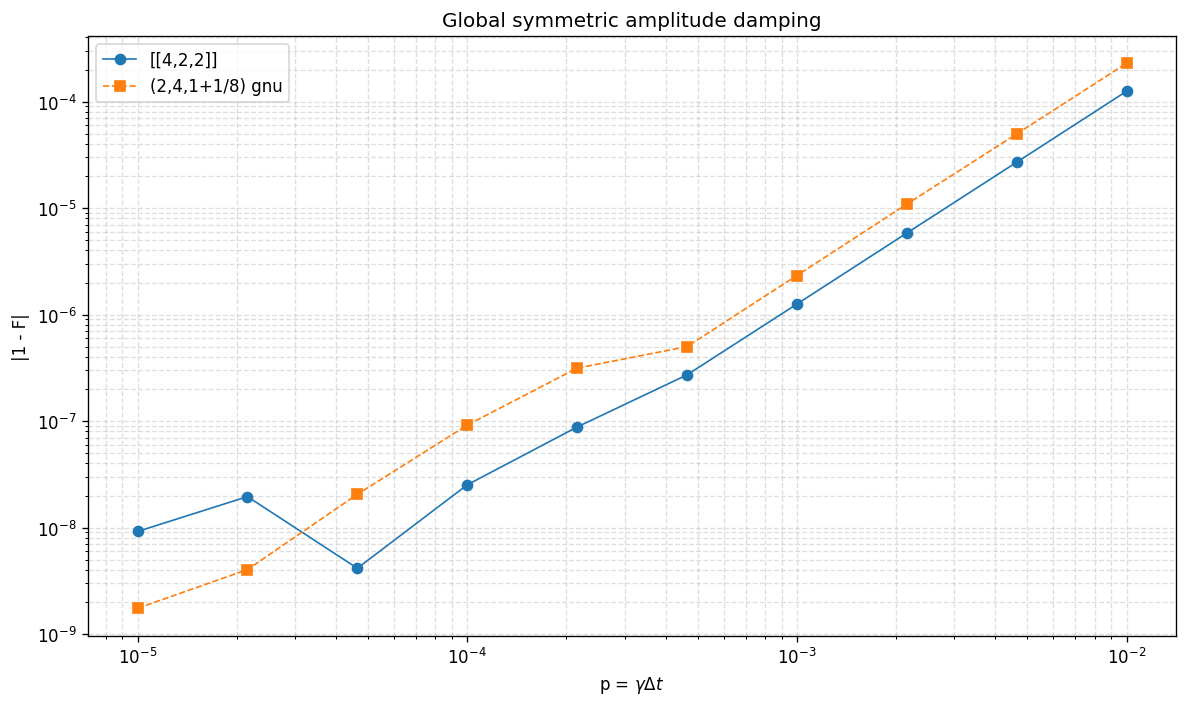

In [16]:
p = [
    1.00000000e-05,
    2.15443469e-05,
    4.64158883e-05,
    1.00000000e-04,
    2.15443469e-04,
    4.64158883e-04,
    1.00000000e-03,
    2.15443469e-03,
    4.64158883e-03,
    1.00000000e-02,]

infid = [
    9.18763798e-09,
    1.95300799e-08,
    4.14945900e-09,
    2.51902592e-08,
    8.79334143e-08,
    2.71470957e-07,
    1.25439115e-06,
    5.82385403e-06,
    2.69428638e-05,
    1.25004362e-04,]
plt.figure(figsize=(10, 6), dpi = 120)
plt.loglog(p, infid, "o-", lw=1, label="[[4,2,2]]") 
plt.loglog(p_vals, infids_local, "s--", lw=1, label=f"(2,4,1+1/8) gnu")
plt.xlabel("p = " + r"$\gamma \Delta t$")
plt.ylabel("|1 - F|")
plt.title("Global symmetric amplitude damping")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
